In [65]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.models as models


In [66]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([.485, .456, .406], [.229, .224, .225])
    ])

# Turning the images in the CroppedImages directory into a dataset
imagePath="D:/SeniorProject/nbaValidation.pt"
dataset = torch.load(imagePath, weights_only=False)

# Creating an 80/20 training/test split
trainSplit = int(.8 * len(dataset))
testSplit = len(dataset) - trainSplit
trainDataset, testDataset = torch.utils.data.random_split(dataset, [trainSplit, testSplit])
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Methods for Pretraining, Training, and Evaluation**

In [68]:
def evaluateModel(model, testLoader):
  
  model.eval()
  correct = 0
  total = 0
  # Testing predictions on test set generated earlier and returning the accuracy
  with torch.no_grad():
    for images, labels in testLoader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy

In [69]:
def pretrainModel(model, numEpochs = 10, batchSize = 256, learningRate = 0.001):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([.485, .456, .406], [.229, .224, .225])
    ])

    trainPath = "D:/SeniorProject/tiny-imagenet-200/train"
    valPath = "D:/SeniorProject/tiny-imagenet-200/val"

    trainDataset = ImageFolder(trainPath, transform=transform)
    valDataset = ImageFolder(valPath, transform=transform)

    trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
    valLoader = DataLoader(valDataset, batch_size=batchSize, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learningRate)
    criterion = nn.CrossEntropyLoss()

    bestWeights = model.state_dict()
    bestAccuracy = 0

    for epoch in range(numEpochs):
        print(f"Epoch {epoch + 1} / {numEpochs}")
        model.train()
        runningLoss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            runningLoss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Debugging information
            if i % 10 == 0:
                print(f"Batch {i}, Loss: {loss.item()}, Correct: {correct}, Total: {total}")


        trainLoss = runningLoss / len(trainLoader.dataset)
        trainAccuracy = correct / total
        print(f"Train Loss: {trainLoss:.4f}, Train Accuracy: {trainAccuracy:.4f}")

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for data in valLoader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        valAccuracy = correct / total
        print(f"Validation Accuracy: {valAccuracy:.4f}")

        if valAccuracy > bestAccuracy:
            bestAccuracy = valAccuracy
            bestWeights = model.state_dict()
    
    print(f"Pretraining Complete.")
    model.load_state_dict(bestWeights)
    return model

In [75]:
def trainModel(model, numEpochs):
    transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([.485, .456, .406], [.229, .224, .225])
    ])

    # Turning the images in the CroppedImages directory into a dataset
    imagePath="D:/SeniorProject/nbaValidation.pt"
    dataset = torch.load(imagePath, weights_only=False)

    # Creating an 80/20 training/test split
    trainSplit = int(.8 * len(dataset))
    testSplit = len(dataset) - trainSplit
    trainDataset, testDataset = torch.utils.data.random_split(dataset, [trainSplit, testSplit])
    trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
    testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

    trainLosses = []
    trainAccuracies = []
    validLosses = []
    validAccuracies = []

    for epoch in range(numEpochs): 
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        trainLosses.append(running_loss / len(trainLoader))
        trainAccuracies.append(correct / total)

        model.eval()

        valLoss = 0
        correct = total = 0
        with torch.no_grad():
            for data in testLoader:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        model.eval()

        validLosses.append(valLoss / len(testLoader))
        validAccuracies.append(correct / total)
        print(f"Epoch {epoch + 1}/{numEpochs}, Train Loss: {trainLosses[-1]:.4f}, Train Accuracy: {trainAccuracies[-1]:.4f}, Validation Loss: {validLosses[-1]:.4f}, Validation Accuracy: {validAccuracies[-1]:.4f}")


    plt.plot(range(1, numEpochs + 1), trainLosses, label="Training Loss", color="blue")
    plt.plot(range(1, numEpochs + 1), validLosses, label="Validation Loss", color="orange")
    plt.plot(range(1, numEpochs + 1), validAccuracies, label="Validation Accuracy", color="green") # This is not working
    plt.xlabel("Epoch")
    plt.ylabel("Loss/Accuracy")
    plt.title("Statistics vs. Epochs")
    plt.legend()
    plt.show()
    
    return model

# **Custom Model**

In [76]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) 
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 30)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

**Baseline**

Epoch 1/15, Train Loss: 3.4194, Train Accuracy: 0.0462, Validation Loss: 3.3150, Validation Accuracy: 0.0534
Epoch 2/15, Train Loss: 3.2062, Train Accuracy: 0.0814, Validation Loss: 3.2684, Validation Accuracy: 0.0777
Epoch 3/15, Train Loss: 2.9116, Train Accuracy: 0.1555, Validation Loss: 3.1883, Validation Accuracy: 0.0922
Epoch 4/15, Train Loss: 2.4073, Train Accuracy: 0.3475, Validation Loss: 3.3783, Validation Accuracy: 0.1019
Epoch 5/15, Train Loss: 1.3647, Train Accuracy: 0.6258, Validation Loss: 4.1391, Validation Accuracy: 0.0680
Epoch 6/15, Train Loss: 0.4458, Train Accuracy: 0.9004, Validation Loss: 5.0824, Validation Accuracy: 0.0874
Epoch 7/15, Train Loss: 0.0954, Train Accuracy: 0.9854, Validation Loss: 5.4107, Validation Accuracy: 0.1262
Epoch 8/15, Train Loss: 0.0339, Train Accuracy: 0.9927, Validation Loss: 5.6270, Validation Accuracy: 0.1262
Epoch 9/15, Train Loss: 0.0098, Train Accuracy: 0.9988, Validation Loss: 5.8850, Validation Accuracy: 0.1068
Epoch 10/15, Train 

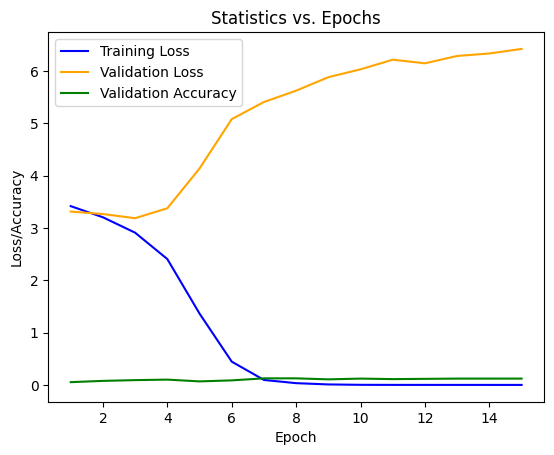

Accuracy: 79.12621359223301


In [77]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 15)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

In [79]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(testLoader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
  
        print(f"\nBatch {batch_idx + 1}:")
        print(f"Labels:      {labels.cpu().numpy()}")
        print(f"Predictions: {predicted.cpu().numpy()}")


Batch 1:
Labels:      [28 14 20  8 25 25  0  4  8  9 17  7 21 18  3 19 25 25  2 19 12 13 27  4
 14 27  0 29  6  1 19 20]
Predictions: [24 14 24  8 25 25  0  4  2  9 17  7 21 18  3 19 25 25  2 19 12 13  3  4
  1  3  0 29  6  1 19 20]

Batch 2:
Labels:      [ 3 22 20 17 27  4  0 13 21 11 25  9  2  9 24 26 29 16 21  8  5 24 14 22
 17 28 24  9  6 13 20  2]
Predictions: [ 3 22 20 27 27  4  0 24 21 11 13  9  2  9 24 26 29 16  2  3  5 13 14 22
 27  4 24 14  6 13 20 21]

Batch 3:
Labels:      [11 12 17 18  2 10  9  3  0 28 14 29 18  8  1 13 11  6 27 27 26  2 25  8
  7 24 18 27 13 22 21  3]
Predictions: [11 12  3 26  2 10  9 12  0 28 14 29 18  8  1 13 11  6 27 13 26  2 13  8
 24 24 18 13 13 22 21 22]

Batch 4:
Labels:      [13  4 25 16  2 11  6 24 17 10 22  0 19 18 21 21  3 13 14  4 25  6  5 26
 25 23 13 12 29 21 22  7]
Predictions: [13  4 25 16  2 11 14 24 17 16 22  0 19 18 21 10  3 13 14  4  4  6  5 26
 25 23 13 12 29 21 22  7]

Batch 5:
Labels:      [10 29  9  6 19 23 19  1 11  0 10  6 12  

In [19]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 10)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

In [20]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 10)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

In [22]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 20)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

In [124]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.fc3 = nn.Linear(84, 200)
model = pretrainModel(model)
model._save_to_state_dict("D:/SeniorProject/pretrained_weights.pt")

In [121]:
model.fc3 = nn.Linear(84, 30)
model = model.to(device)
model = trainModel(model, 10)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

# **Sequential Model**

In [23]:
class LeNet5(nn.Module):
        def __init__(self, num_classes):
            super(LeNet5, self).__init__()
            self.layer1 = nn.Sequential(
                nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=0),
                nn.BatchNorm2d(6),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2, stride = 2))
            self.layer2 = nn.Sequential(
                nn.Conv2d(6, 16, kernel_size=5, stride=3, padding=0),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2, stride = 2))
            self.fc = nn.Linear(16 * 18 * 18, 120)
            self.relu = nn.ReLU()
            self.fc1 = nn.Linear(120, 84)
            self.relu1 = nn.ReLU()
            self.fc2 = nn.Linear(84, num_classes)
            
        def forward(self, x):
            out = self.layer1(x)
            out = self.layer2(out)
            out = out.reshape(out.size(0), -1)
            out = self.fc(out)
            out = self.relu(out)
            out = self.fc1(out)
            out = self.relu1(out)
            out = self.fc2(out)
            return out

In [24]:
model = LeNet5(30).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 20)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

In [25]:
model = models.resnet18()
model.fc = nn.Linear(512, 30)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = trainModel(model, 30)
print(f"Accuracy: {evaluateModel(model, testLoader):.4f}%")